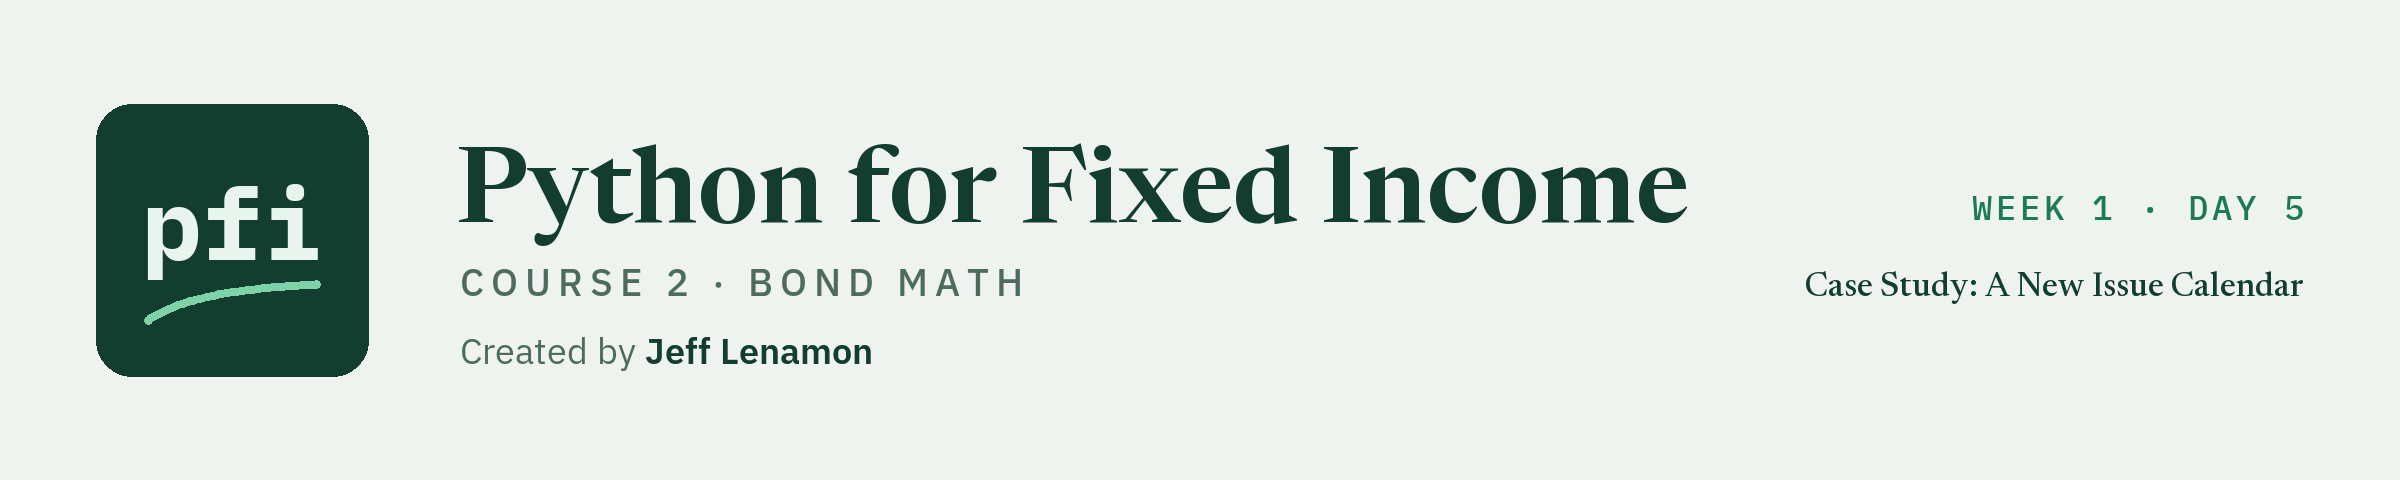

# Case Study: A New Issue Calendar

Week 1, Day 5. A case study to close week 1: a desk's calendar of eight invented new issues, described with the week's functions, checked against Excel, and written to a workbook of live Excel formulas.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day5/05_case_study_a_new_issue_calendar.ipynb)

Four days built four tools: time value, price from yield, the price-yield relationship, and yield from price. Today puts them to work on one job from start to finish, as Course 1's first case study did.

The job is a **new issue calendar**: the list a desk works through on a busy day, with eight invented companies selling new bonds. The calendar gives each issue's coupon, term, and **re-offer price**, the price at which the new bonds are sold to investors. You will describe the calendar with your own module, check every number against Excel, and finish with a workbook that Excel calculates for itself.

Like Course 1's case study, the notebook asks six **Predict** questions. Each one shows a question and three answers before the code runs. Decide, then run the cell.

The issuers and every number on the calendar are invented. Nothing here says an issue is attractive, cheap, or rich: every number describes the calendar.

The setup cell is the same as yesterday's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 4.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_05_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_05_exidll2b, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price']


* The two files exactly as day 4 left them: six functions and 11 tests. Today adds no function. The module already does everything the calendar needs, and the day adds two tests.

Record the starting point in Git first, as on days 2 to 4.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_05_exidll2b and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 5: bondmath.py and test_bondmath.py as day 4 left them"
!git -C "{work}" log --oneline

e08f979 Start of day 5: bondmath.py and test_bondmath.py as day 4 left them


* One commit, the start of day 5. Its hash changes on every run.

## Problem Definition

### Context

A credit desk's morning run lists eight new corporate bonds pricing today. Each one is a fixed-rate bullet that pays a coupon twice a year on the 30/360 day count and settles on 30 September 2026, the day it is issued. A new bond settles on its issue date, so it has accrued nothing yet: settlement is the start of the first coupon period, and the coupon-date functions of days 2 and 4 apply exactly.

### Objective

You are the desk's analyst. Describe the calendar with your module:

* the yield behind each re-offer price,
* every issue priced at one common yield, so coupons and terms can be compared on equal terms,
* the coupon, on the market's grid of eighths, that would price each issue nearest par at its own yield,
* what one eighth of coupon is worth in price,
* all of it as columns of one DataFrame, checked against Excel's numbers,
* and a workbook whose yield and price columns are live Excel formulas, for Excel to check.

### The data

The calendar, as the desk typed it. The issuers are invented, taken from the course's list of issuers, and so are the CUSIPs.

| CUSIP | Issuer | Rating | Coupon (%) | Years | Maturity | Re-offer price |
| --- | --- | --- | --- | --- | --- | --- |
| 99010KZA6 | Thalostrin Finance | BBB+ | 5.125 | 5 | 2031-09-30 | 99.874 |
| 99011LZA3 | Galvostrin Resources | BBB+ | 5.625 | 10 | 2036-09-30 | 99.512 |
| 99012MZA0 | Hulvimer Pipeline | BBB | 5.5 | 7 | 2033-09-30 | 99.760 |
| 99013NZA7 | Kezerone Paper | A- | 4.625 | 3 | 2029-09-30 | 99.942 |
| 99014OZA4 | Elvorin Medical | BB- | 7.875 | 8 | 2034-09-30 | 100.000 |
| 99016QZA7 | Corvolvey Systems | BB+ | 7 | 5 | 2031-09-30 | 99.000 |
| 99017RZA4 | Rulvolvey Industrial | BBB- | 6 | 30 | 2056-09-30 | 98.975 |
| 99020UZA2 | Morvithe Logistics | B | 8.75 | 6 | 2032-09-30 | 98.500 |

### How we will solve it

One section for each item of the objective, each built from the module's two pricing functions. Along the way, six Predict questions. The answers come from running the code, not from a view on any issuer.

Q. Type in the calendar, and check what was typed.

In [8]:
calendar = pd.DataFrame({
    "cusip": ['99010KZA6', '99011LZA3', '99012MZA0', '99013NZA7', '99014OZA4', '99016QZA7', '99017RZA4', '99020UZA2'],
    "issuer": ['Thalostrin Finance', 'Galvostrin Resources', 'Hulvimer Pipeline', 'Kezerone Paper', 'Elvorin Medical', 'Corvolvey Systems', 'Rulvolvey Industrial', 'Morvithe Logistics'],
    "ticker": ['THAN', 'GALN', 'HULR', 'KEZE', 'ELVN', 'CORY', 'RULY', 'MORE'],
    "rating": ['BBB+', 'BBB+', 'BBB', 'A-', 'BB-', 'BB+', 'BBB-', 'B'],
    # the annual coupon in percent, and the years from settlement on 30 September 2026 to maturity
    "coupon_pct": [5.125, 5.625, 5.5, 4.625, 7.875, 7.0, 6.0, 8.75],
    "years": [5, 10, 7, 3, 8, 5, 30, 6],
    "maturity": ['2031-09-30', '2036-09-30', '2033-09-30', '2029-09-30', '2034-09-30', '2031-09-30', '2056-09-30', '2032-09-30'],
    # the re-offer price, per 100 of face
    "reoffer_price": [99.874, 99.512, 99.76, 99.942, 100.0, 99.0, 98.975, 98.5],
})

# data typed by hand is checked before it is used: eight issues, eight different CUSIPs
assert len(calendar) == 8 and calendar["cusip"].is_unique, "the calendar should hold eight different issues"
# coupons are set in eighths of a point: eight times the coupon is a whole number
assert ((calendar["coupon_pct"] * 8) % 1 == 0).all(), "a coupon is not on the grid of eighths"

calendar

,cusip,issuer,ticker,rating,coupon_pct,years,maturity,reoffer_price
0,99010KZA6,Thalostrin Finance,THAN,BBB+,5.125,5,2031-09-30,99.874
1,99011LZA3,Galvostrin Resources,GALN,BBB+,5.625,10,2036-09-30,99.512
2,99012MZA0,Hulvimer Pipeline,HULR,BBB,5.500,7,2033-09-30,99.760
3,99013NZA7,Kezerone Paper,KEZE,A-,4.625,3,2029-09-30,99.942
4,99014OZA4,Elvorin Medical,ELVN,BB-,7.875,8,2034-09-30,100.000
5,99016QZA7,Corvolvey Systems,CORY,BB+,7.000,5,2031-09-30,99.000
6,99017RZA4,Rulvolvey Industrial,RULY,BBB-,6.000,30,2056-09-30,98.975
7,99020UZA2,Morvithe Logistics,MORE,B,8.750,6,2032-09-30,98.500


* Eight issues, every CUSIP different, every coupon a whole number of eighths. Both `assert` lines stayed silent, so both checks passed.
* `% 1` is the remainder after dividing by 1, the part after the decimal point. For 5.125 times 8, which is 41.0, it is 0.

## 5.1 Yields from Re-offer Prices

The calendar gives prices. Day 4's `yield_from_price` turns each price into the yield that makes issues comparable.

Q. What does Thalostrin Finance yield at its re-offer price of 99.874?

In [9]:
thalostrin = calendar.iloc[0]
thalostrin_yield_pct = bondmath.yield_from_price(thalostrin["coupon_pct"], thalostrin["reoffer_price"], thalostrin["years"])

print(f"{thalostrin['issuer']}: a {thalostrin['coupon_pct']} percent coupon at {thalostrin['reoffer_price']} yields {thalostrin_yield_pct:.4f} percent")

Thalostrin Finance: a 5.125 percent coupon at 99.874 yields 5.1539 percent


* 5.1539 percent, a little above the 5.125 percent coupon, because the price is a little below 100: day 3's rule.

**Predict 1**

Two issues on the calendar are re-offered about a point below 100: Corvolvey Systems, a 7 percent 5-year bond at 99.000, and Rulvolvey Industrial, a 6 percent 30-year bond at 98.975. Each yields more than its coupon. Which one's yield is further above its coupon?

> A) Rulvolvey, because its discount is slightly larger.
>
> B) About the same for both, because the discounts are about the same.
>
> C) Corvolvey, because its discount is spread over far fewer years.

Decide, then run the cell.

In [10]:
for ticker in ["CORY", "RULY"]:
    issue = calendar[calendar["ticker"] == ticker].iloc[0]
    issue_yield_pct = bondmath.yield_from_price(issue["coupon_pct"], issue["reoffer_price"], issue["years"])
    # percentage points times 100 is basis points
    above_bp = (issue_yield_pct - issue["coupon_pct"]) * 100
    print(f"{issue['issuer']}, {issue['years']} years at {issue['reoffer_price']}: yield {issue_yield_pct:.4f} percent, "
          f"{above_bp:.1f} bp above the coupon")

Corvolvey Systems, 5 years at 99.0: yield 7.2420 percent, 24.2 bp above the coupon
Rulvolvey Industrial, 30 years at 98.975: yield 6.0747 percent, 7.5 bp above the coupon


* The answer is C. Corvolvey's yield is 24.2 basis points above its coupon, Rulvolvey's only 7.5.
* The buyer of each bond gets 100 back at maturity for about 99 paid. On a 5-year bond that point of discount is earned over 5 years; on a 30-year bond over 30. Spread over more years, the same discount adds less to the yield each year. Exercise 2 of day 4 found the same thing from the other side: a point of price moves a short bond's yield more.

Q. Now the whole calendar: a yield for every issue, and how far each is above its coupon.

In [11]:
# one issue at a time: zip hands the function each row's coupon, price, and years together
calendar["yield_pct"] = [
    bondmath.yield_from_price(c, p, t) for c, p, t in zip(calendar["coupon_pct"], calendar["reoffer_price"], calendar["years"])
]
calendar["yield_minus_coupon_bp"] = (calendar["yield_pct"] - calendar["coupon_pct"]) * 100

calendar[["issuer", "coupon_pct", "years", "reoffer_price", "yield_pct", "yield_minus_coupon_bp"]].round(4)

,issuer,coupon_pct,years,reoffer_price,yield_pct,yield_minus_coupon_bp
0,Thalostrin Finance,5.125,5,99.874,5.1539,2.8908
1,Galvostrin Resources,5.625,10,99.512,5.6897,6.4665
2,Hulvimer Pipeline,5.500,7,99.760,5.5418,4.1832
3,Kezerone Paper,4.625,3,99.942,4.6459,2.0935
4,Elvorin Medical,7.875,8,100.000,7.8750,-0.0000
5,Corvolvey Systems,7.000,5,99.000,7.2420,24.1951
6,Rulvolvey Industrial,6.000,30,98.975,6.0747,7.4666
7,Morvithe Logistics,8.750,6,98.500,9.0797,32.9749


* Seven issues are re-offered below 100, and each yields more than its coupon, from 2.1 basis points (Kezerone Paper) to 33.0 (Morvithe Logistics).
* Elvorin Medical is re-offered at exactly 100, so its yield is its coupon, 7.875 percent: day 3's par bond. The last column shows -0.0000 for it: zero to four decimals, with the minus sign left by the last digits of the search.

Q. Does Excel's `YIELD` agree? The reference file holds `YIELD` of each re-offer price.

In [12]:
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")

# the first eight CALENDAR_YIELD rows are this calendar, in the same order. YIELD returns a decimal, so times 100
yield_rows = tvm[tvm["function"] == "CALENDAR_YIELD"].head(8)
calendar["excel_yield_pct"] = (yield_rows["excel_value"] * 100).to_numpy()

largest_gap = (calendar["yield_pct"] - calendar["excel_yield_pct"]).abs().max()
assert largest_gap < 1e-6, "a yield differs from Excel's"
print(f"Largest gap to Excel's YIELD: {largest_gap:.1e} percent")
yield_rows[["case_id", "excel_formula", "excel_value"]].head(3)

Largest gap to Excel's YIELD: 6.1e-09 percent


,case_id,excel_formula,excel_value
119,tvm_calendar_yield_01,"=YIELD(DATE(2026,9,30),DATE(2031,9,30),5.125/1...",0.051539
120,tvm_calendar_yield_02,"=YIELD(DATE(2026,9,30),DATE(2036,9,30),5.625/1...",0.056897
121,tvm_calendar_yield_03,"=YIELD(DATE(2026,9,30),DATE(2033,9,30),5.5/100...",0.055418


* All eight agree with Excel to well within the course's tolerance of 1e-6 percent.

**Excel side by side.** Tested in Excel. For Thalostrin, type `=YIELD(DATE(2026,9,30),DATE(2031,9,30),5.125/100,99.874,100,2,0)` in a cell. Settlement, maturity, the coupon as a decimal, the re-offer price per 100, redemption 100, two coupons a year, and basis 0 for 30/360. Excel returns 0.0515390782041645, a decimal. Multiply by 100 for percent: 5.153908, the same as `yield_from_price`.

## 5.2 Prices at a Common Yield

The re-offer yields differ for two reasons at once: each issuer's credit, and each bond's term. To see what the coupon and the term do on their own, price every issue at one yield. The course uses 5.50 percent, a round number chosen for the exercise: it is not a market level for any issuer, and the prices it gives are what-ifs.

At a common yield, day 3's rule sorts the calendar: a coupon above 5.50 prices above 100, a coupon below it prices below 100, and a coupon equal to it prices at 100.

**Predict 2**

Corvolvey Systems pays 7 percent for 5 years. Rulvolvey Industrial pays 6 percent for 30 years. Both coupons are above 5.50, so both price above 100. Priced at the same 5.50 percent, which price is higher?

> A) Corvolvey, because its coupon is a full point higher.
>
> B) Rulvolvey, even though its coupon is lower.
>
> C) The same, because they are priced at the same yield.

Decide, then run the cell.

In [13]:
common_yield_pct = 5.5

for ticker in ["CORY", "RULY"]:
    issue = calendar[calendar["ticker"] == ticker].iloc[0]
    price = bondmath.price_from_yield(issue["coupon_pct"], common_yield_pct, issue["years"])
    # the coupon above the common yield, paid each half-year, per 100 of face
    extra_per_half_year = (issue["coupon_pct"] - common_yield_pct) / 2
    print(f"{issue['issuer']}: {extra_per_half_year:.3f} a half-year above {common_yield_pct} percent, "
          f"for {issue['years'] * 2} half-years. Price at {common_yield_pct} percent: {price:.4f}")

Corvolvey Systems: 0.750 a half-year above 5.5 percent, for 10 half-years. Price at 5.5 percent: 106.4801
Rulvolvey Industrial: 0.250 a half-year above 5.5 percent, for 60 half-years. Price at 5.5 percent: 107.3057


* The answer is B. Rulvolvey prices at 107.3057 and Corvolvey at 106.4801.
* Corvolvey's coupon is 0.750 a half-year above what 5.50 percent would pay, but only for 10 half-years. Rulvolvey's is 0.250 above, for 60 half-years. The price above 100 is the value today of all those extra coupons, so a small extra paid for a long time can be worth more than a large extra paid for a short time. It is day 3's finding that the longer bond moves more, seen through the coupon.

Q. Price the whole calendar at 5.50 percent, and compare with Excel's `PRICE`.

In [14]:
calendar["price_at_5_50"] = [bondmath.price_from_yield(c, common_yield_pct, t) for c, t in zip(calendar["coupon_pct"], calendar["years"])]

# the first eight CALENDAR_PRICE rows are this calendar at 5.50 percent, in the same order
price_rows = tvm[tvm["function"] == "CALENDAR_PRICE"].head(8)
calendar["excel_price_at_5_50"] = price_rows["excel_value"].to_numpy()

largest_gap = (calendar["price_at_5_50"] - calendar["excel_price_at_5_50"]).abs().max()
assert largest_gap < 1e-6, "a price differs from Excel's"
print(f"Largest gap to Excel's PRICE: {largest_gap:.1e} per 100 of face")
calendar[["issuer", "coupon_pct", "years", "price_at_5_50", "excel_price_at_5_50"]].round(4)

Largest gap to Excel's PRICE: 1.1e-13 per 100 of face


,issuer,coupon_pct,years,price_at_5_50,excel_price_at_5_50
0,Thalostrin Finance,5.125,5,98.3800,98.3800
1,Galvostrin Resources,5.625,10,100.9517,100.9517
2,Hulvimer Pipeline,5.500,7,100.0000,100.0000
3,Kezerone Paper,4.625,3,97.6102,97.6102
4,Elvorin Medical,7.875,8,115.2054,115.2054
5,Corvolvey Systems,7.000,5,106.4801,106.4801
6,Rulvolvey Industrial,6.000,30,107.3057,107.3057
7,Morvithe Logistics,8.750,6,116.4193,116.4193


* Hulvimer Pipeline's coupon is 5.50 percent, so it prices at 100. Thalostrin and Kezerone pay less than 5.50 and price below 100; the other five pay more and price above.
* Excel agrees to within 1.1e-13. Excel's Hulvimer price is 99.99999999999993, 7e-14 below 100: a floating-point difference in the last digits, far inside the tolerance.

**Excel side by side.** Tested in Excel. For Rulvolvey, `=PRICE(DATE(2026,9,30),DATE(2056,9,30),6/100,5.5/100,100,2,0)` returns 107.30566550271652, and for Corvolvey `=PRICE(DATE(2026,9,30),DATE(2031,9,30),7/100,5.5/100,100,2,0)` returns 106.4800571225415. Both rates go in as decimals, written `/100`.

## 5.3 The Coupon That Prices Nearest Par on a 1/8 Grid

Coupons are not set to any decimal. They are set on a grid of eighths of a percent: 5.500, 5.625, 5.750, and so on, as the `assert` on the calendar checked. Day 3 showed that a bond whose coupon equals its yield prices at 100. A yield is rarely a whole number of eighths, so the question becomes: at each issue's own yield, which coupon on the grid prices nearest 100?

The direct way is to try the two grid coupons either side of the yield, price each one at that yield, and keep the price nearer 100.

**Predict 3**

Galvostrin Resources yields 5.6897 percent at its re-offer price. The grid coupons either side are 5.625, 6.5 basis points below the yield and the coupon on the calendar, and 5.750, 6.0 basis points above. At Galvostrin's yield, on its 10-year term, which coupon prices nearer 100?

> A) 5.625, the coupon on the calendar.
>
> B) 5.750, the grid coupon nearer the yield.
>
> C) Neither: on a 10-year bond the two prices are the same distance from 100.

Decide, then run the cell.

In [15]:
# math has floor (round down to a whole number) and ceil (round up)
import math

galvostrin = calendar[calendar["ticker"] == "GALN"].iloc[0]
step_pct = 0.125

# the grid coupons either side of the yield: round down and up to a whole number of eighths
yield_pct = galvostrin["yield_pct"]
for coupon_pct in [math.floor(yield_pct / step_pct) * step_pct, math.ceil(yield_pct / step_pct) * step_pct]:
    price = bondmath.price_from_yield(coupon_pct, yield_pct, galvostrin["years"])
    print(f"Coupon {coupon_pct:.3f} at a yield of {yield_pct:.4f} percent: price {price:.4f}, {abs(price - 100):.4f} from 100")

Coupon 5.625 at a yield of 5.6897 percent: price 99.5120, 0.4880 from 100
Coupon 5.750 at a yield of 5.6897 percent: price 100.4553, 0.4553 from 100


* The answer is B: 5.750 prices at 100.4553, 0.4553 from 100, and 5.625 at 99.5120, 0.4880 from 100.
* The reason: **price is a straight line in the coupon.** Every extra eighth of coupon adds the same amount to the price, at a given yield and term. The line crosses 100 at the yield, so the grid coupon nearer the yield is nearer 100 in price too. The term changes how steep the line is, not where it crosses 100. Section 5.4 measures the steepness.

Q. Find the grid coupon nearest par for every issue, at its own yield.

In [16]:
def nearest_par_coupon(yield_pct, years, step_pct=0.125):
    """The grid coupon either side of yield_pct whose price at yield_pct is nearer 100."""
    candidates = [math.floor(yield_pct / step_pct) * step_pct, math.ceil(yield_pct / step_pct) * step_pct]
    distances = [abs(bondmath.price_from_yield(c, yield_pct, years) - 100) for c in candidates]
    # keep the candidate with the smaller distance from 100
    return candidates[distances.index(min(distances))]


calendar["par_coupon_pct"] = [nearest_par_coupon(y, t) for y, t in zip(calendar["yield_pct"], calendar["years"])]
calendar["price_at_par_coupon"] = [
    bondmath.price_from_yield(c, y, t) for c, y, t in zip(calendar["par_coupon_pct"], calendar["yield_pct"], calendar["years"])
]

calendar[["issuer", "coupon_pct", "yield_pct", "par_coupon_pct", "price_at_par_coupon"]].round(4)

,issuer,coupon_pct,yield_pct,par_coupon_pct,price_at_par_coupon
0,Thalostrin Finance,5.125,5.1539,5.125,99.8740
1,Galvostrin Resources,5.625,5.6897,5.750,100.4553
2,Hulvimer Pipeline,5.500,5.5418,5.500,99.7600
3,Kezerone Paper,4.625,4.6459,4.625,99.9420
4,Elvorin Medical,7.875,7.8750,7.875,100.0000
5,Corvolvey Systems,7.000,7.2420,7.250,100.0333
6,Rulvolvey Industrial,6.000,6.0747,6.125,100.6910
7,Morvithe Logistics,8.750,9.0797,9.125,100.2058


* For four issues the coupon nearest par is the calendar's own coupon, and each of them prices at its re-offer price, at or just below 100.
* For the other four the coupon nearest par is above the calendar's coupon: one eighth above for Galvostrin and Rulvolvey, two for Corvolvey, three for Morvithe. Each of these yields sits more than a sixteenth above its coupon, so a higher eighth is nearer; the further below 100 an issue is re-offered for its term, the more eighths separate its coupon from par.
* Every coupon in the column is also the grid coupon nearest the yield, as the straight line says it must be. Exercise 3 turns that shortcut into a function.

**Excel side by side.** Tested in Excel. `MROUND` rounds a number to the nearest multiple of another: `=MROUND(5.69,0.125)` returns 5.75, Galvostrin's grid coupon from its yield rounded to two decimals. The yield here is in percent and stays in percent, because `MROUND` is not an interest rate argument: it only rounds.

## 5.4 The Price Effect of a 1/8 Coupon Step

Section 5.3 said every extra eighth of coupon adds the same amount to the price. How much is that amount? It is the price of an extra 0.0625 per 100 of face every half-year, an eighth of a percent a year split in two, for the life of the bond.

**Predict 4**

Rulvolvey Industrial is a 30-year bond. Priced at 5.50 percent, how much does its price rise if its coupon is one eighth higher, 6.125 instead of 6.000?

> A) 0.125, one eighth of a point.
>
> B) About 1.8, a good deal less than an eighth for every year.
>
> C) 3.75, an eighth for each of its 30 years.

Decide, then run the cell.

In [17]:
rulvolvey = calendar[calendar["ticker"] == "RULY"].iloc[0]

price_now = bondmath.price_from_yield(rulvolvey["coupon_pct"], common_yield_pct, rulvolvey["years"])
price_stepped = bondmath.price_from_yield(rulvolvey["coupon_pct"] + 0.125, common_yield_pct, rulvolvey["years"])

print(f"Coupon {rulvolvey['coupon_pct']:.3f}: {price_now:.4f}. Coupon {rulvolvey['coupon_pct'] + 0.125:.3f}: {price_stepped:.4f}")
print(f"One eighth of coupon adds {price_stepped - price_now:.4f} per 100 of face")

Coupon 6.000: 107.3057. Coupon 6.125: 109.1321
One eighth of coupon adds 1.8264 per 100 of face


* The answer is B: 1.8264. An eighth for every year would be 3.75, but only if money paid in 30 years were worth as much as money paid today. Each extra 0.0625 is discounted back from the half-year it is paid, as on day 1, and the 60 discount factors at 5.50 percent add up to 29.2227. So the step is 0.0625 times 29.2227.

Q. What is one eighth of coupon worth on every issue, at 5.50 percent?

In [18]:
calendar["step_value"] = [
    bondmath.price_from_yield(c + 0.125, common_yield_pct, t) - bondmath.price_from_yield(c, common_yield_pct, t)
    for c, t in zip(calendar["coupon_pct"], calendar["years"])
]

calendar[["issuer", "coupon_pct", "years", "step_value"]].sort_values("years").round(4)

,issuer,coupon_pct,years,step_value
3,Kezerone Paper,4.625,3,0.3414
0,Thalostrin Finance,5.125,5,0.5400
5,Corvolvey Systems,7.000,5,0.5400
7,Morvithe Logistics,8.750,6,0.6315
2,Hulvimer Pipeline,5.500,7,0.7182
4,Elvorin Medical,7.875,8,0.8003
1,Galvostrin Resources,5.625,10,0.9517
6,Rulvolvey Industrial,6.000,30,1.8264


* From 0.3414 on the 3-year bond to 1.8264 on the 30-year bond: the longer the bond, the more an eighth of coupon is worth, and the less than an eighth per year.
* Thalostrin and Corvolvey, both 5-year bonds, show the same 0.5400, although their coupons are almost two points apart. At a given yield and term the step does not depend on the coupon: that is what a straight line means.
* `sort_values("years")` orders the rows by term, shortest first, for reading. It changes only what is shown, not the `calendar` DataFrame.

**Excel side by side.** Tested in Excel. The step for Rulvolvey is two `PRICE` cells subtracted: `=PRICE(DATE(2026,9,30),DATE(2056,9,30),6.125/100,5.5/100,100,2,0)-PRICE(DATE(2026,9,30),DATE(2056,9,30),6/100,5.5/100,100,2,0)`. The two `PRICE` values in the reference file are 109.13208187839575 and 107.30566550271652, so the difference is 1.826416.

## 5.5 The Calendar as a DataFrame

Every result so far went into `calendar` as a new column, built one issue at a time with `zip` and a list comprehension. A DataFrame column can be handed to many functions whole, as Course 1 did with `.sum()` and arithmetic on columns, so why not hand the three columns straight to `yield_from_price`?

**Predict 5**

The cell below calls `yield_from_price` once, with three whole columns instead of three numbers. What happens?

> A) A column of eight yields, the same as the list comprehension.
>
> B) An error.
>
> C) One yield, for the first issue.

Decide, then run the cell.

In [19]:
# hand the three whole columns to the function at once
try:
    calendar["yield_pct"] = bondmath.yield_from_price(calendar["coupon_pct"], calendar["reoffer_price"], calendar["years"])
except ValueError as error:
    # print the kind of error and its message, the last line of a traceback
    print(f"ValueError: {error}")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


* The answer is B. The message is pandas saying that the truth value of a whole column is ambiguous.
* The module's functions make decisions with `if`: `cash_flows` checks that the years are a whole number of periods, and `yield_from_price` checks the price is inside its bracket. `if` needs one `True` or `False`. A comparison on a column gives eight of them, one per issue, and Python will not guess whether you meant all of them or any of them.
* So the module works on one bond at a time, and the list comprehension hands it the issues one at a time. Plain functions of numbers keep the module simple and match Excel's functions one to one, which is the reason the course gave for not building a `Bond` class.

Q. Show the whole calendar with the columns the module produced.

In [20]:
summary_columns = ["ticker", "rating", "coupon_pct", "years", "reoffer_price", "yield_pct", "price_at_5_50",
                   "par_coupon_pct", "step_value"]

# the results must line up with the inputs: one row per issue, and nothing missing
assert len(calendar) == 8 and calendar[summary_columns].notna().all().all(), "a result is missing"
calendar[summary_columns].round(4)

,ticker,rating,coupon_pct,years,reoffer_price,yield_pct,price_at_5_50,par_coupon_pct,step_value
0,THAN,BBB+,5.125,5,99.874,5.1539,98.3800,5.125,0.5400
1,GALN,BBB+,5.625,10,99.512,5.6897,100.9517,5.750,0.9517
2,HULR,BBB,5.500,7,99.760,5.5418,100.0000,5.500,0.7182
3,KEZE,A-,4.625,3,99.942,4.6459,97.6102,4.625,0.3414
4,ELVN,BB-,7.875,8,100.000,7.8750,115.2054,7.875,0.8003
5,CORY,BB+,7.000,5,99.000,7.2420,106.4801,7.250,0.5400
6,RULY,BBB-,6.000,30,98.975,6.0747,107.3057,6.125,1.8264
7,MORE,B,8.750,6,98.500,9.0797,116.4193,9.125,0.6315


**Observations**

* The re-offer yields run from 4.6459 percent (Kezerone Paper, rated A-, 3 years) to 9.0797 percent (Morvithe Logistics, rated B, 6 years).
* Seven issues are re-offered below 100 and one at 100. Each yield is at or above its coupon, by at most 33.0 basis points.
* At the common yield of 5.50 percent, five issues price above 100, two below, and one at 100. The two longest bonds hold the most price per point of coupon above 5.50.
* One eighth of coupon is worth from 0.3414 to 1.8264 per 100 of face, rising with the term.
* For four issues the grid coupon nearest par is above the calendar's coupon, by one to three eighths.

These describe the calendar. None of them says which issue anyone should buy.

Two facts carried the whole case study: a coupon equal to the yield prices at 100 (sections 5.2 and 5.3), and price falls as yield rises (sections 5.1 and 5.3). Both are true for every bond, not only these eight, so they belong in the test file.

Q. Add the two tests.

In [21]:
%%writefile -a test_bondmath.py


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier

Appending to test_bondmath.py


* `test_par_bond_prices_at_100` prices a 5.5 percent coupon at a 5.5 percent yield for 1, 2, 5, 10, and 30 years at each of the three frequencies: fifteen bonds, every one at 100 within 1e-9.
* `test_price_falls_as_yield_rises` prices one 10-year bond at six yields from 2 to 12 percent, and `zip(prices, prices[1:])` pairs each price with the next one, so every step up in yield must give a lower price.
* Neither test reads a reference file. Each checks a rule that holds for every bond, which is a different kind of test from matching Excel row by row.

Q. Run the tests.

In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.............                                                            [100%]
13 passed in 0.04s



* 13 dots and `13 passed`: the 11 from days 1 to 4, and today's two.

## 5.6 The Workbook for Excel

Last, the calendar goes to Excel, and Excel checks the module one more time. Not as numbers pasted in, but as **live formulas**: the workbook's yield and price columns hold `YIELD` and `PRICE` formulas that read the coupon, maturity, and re-offer price from the same row. Beside each formula column sits Python's number, and beside that a gap column, Excel's number minus Python's.

The library is **openpyxl**, which reads and writes Excel's `.xlsx` files. It was installed with the course's `requirements.txt`, and pandas uses it for `to_excel`. Here it is used directly, because a cell whose text starts with `=` is written as a formula.

Q. Write the calendar to a workbook in the work folder.

In [23]:
from datetime import date

from openpyxl import Workbook

workbook = Workbook()
sheet = workbook.active
sheet.title = "calendar"

# row 1: the headers
sheet.append(["cusip", "issuer", "coupon_pct", "maturity", "reoffer_price", "python_yield_pct", "excel_yield_pct",
              "yield_gap", "python_price_at_5_50", "excel_price_at_5_50", "price_gap"])

# one row per issue: the inputs and Python's numbers as values, Excel's as formulas that read the same row
for r, issue in enumerate(calendar.itertuples(), start=2):
    sheet.append([
        issue.cusip,
        issue.issuer,
        issue.coupon_pct,
        date.fromisoformat(issue.maturity),
        issue.reoffer_price,
        issue.yield_pct,
        f"=YIELD(DATE(2026,9,30),D{r},C{r}/100,E{r},100,2,0)*100",
        f"=G{r}-F{r}",
        issue.price_at_5_50,
        f"=PRICE(DATE(2026,9,30),D{r},C{r}/100,5.5/100,100,2,0)",
        f"=J{r}-I{r}",
    ])

# how Excel shows each column: dates as dates, six decimals for yields and prices, gaps in scientific notation
for row in sheet.iter_rows(min_row=2):
    row[3].number_format = "yyyy-mm-dd"
    for cell in (row[5], row[6], row[8], row[9]):
        cell.number_format = "0.000000"
    for cell in (row[7], row[10]):
        cell.number_format = "0.0E+00"
# wide enough columns for the numbers to show
for letter in "ABCDEFGHIJK":
    sheet.column_dimensions[letter].width = 22

# no folder in the name: the file goes into the work folder, never into the course repo
workbook.save("new_issue_calendar.xlsx")
print(f"Saved new_issue_calendar.xlsx in {work.name}")
print(f'To open it from PowerShell:  Invoke-Item "$env:TEMP\\{work.name}\\new_issue_calendar.xlsx"')

Saved new_issue_calendar.xlsx in pfi_course2_05_exidll2b
To open it from PowerShell:  Invoke-Item "$env:TEMP\pfi_course2_05_exidll2b\new_issue_calendar.xlsx"


* `sheet.append` adds one row at the bottom of the sheet. The f-string puts the row number into each formula, so row 2's formulas read row 2, row 3's read row 3, and so on.
* The maturity goes in as a `date`, so Excel receives a real date it can hand to `YIELD` and `PRICE`, not text.
* The workbook is saved in the work folder, as every file today is. The second line prints the PowerShell command that opens it in Excel.

Q. What did openpyxl put in row 2?

In [24]:
# each cell of row 2: its address and what openpyxl stored there
for cell in sheet[2]:
    print(f"{cell.coordinate}: {cell.value!r}")

A2: '99010KZA6'
B2: 'Thalostrin Finance'
C2: 5.125
D2: datetime.date(2031, 9, 30)
E2: 99.874
F2: 5.15390782089753
G2: '=YIELD(DATE(2026,9,30),D2,C2/100,E2,100,2,0)*100'
H2: '=G2-F2'
I2: 98.37998571936456
J2: '=PRICE(DATE(2026,9,30),D2,C2/100,5.5/100,100,2,0)'
K2: '=J2-I2'


* Columns A to F and I hold values. Columns G, H, J, and K hold formula text, starting with `=`, exactly as typed.

**Predict 6**

The workbook is saved. The cell below reads it back with pandas, `pd.read_excel`, the way Course 1 read workbooks. What will the `excel_yield_pct` column hold?

> A) The yields, as Excel would show them.
>
> B) The formula text, starting with `=`.
>
> C) Nothing: empty cells, shown as `NaN`.

Decide, then run the cell.

In [25]:
back = pd.read_excel("new_issue_calendar.xlsx")
back[["cusip", "python_yield_pct", "excel_yield_pct", "yield_gap", "python_price_at_5_50", "excel_price_at_5_50"]]

,cusip,python_yield_pct,excel_yield_pct,yield_gap,python_price_at_5_50,excel_price_at_5_50
0,99010KZA6,5.153908,NaN,NaN,98.379986,NaN
1,99011LZA3,5.689665,NaN,NaN,100.951703,NaN
2,99012MZA0,5.541832,NaN,NaN,100.000000,NaN
3,99013NZA7,4.645935,NaN,NaN,97.610215,NaN
4,99014OZA4,7.875000,NaN,NaN,115.205431,NaN
5,99016QZA7,7.241951,NaN,NaN,106.480057,NaN
6,99017RZA4,6.074666,NaN,NaN,107.305666,NaN
7,99020UZA2,9.079749,NaN,NaN,116.419331,NaN


* The answer is C. Python's own columns come back as written, but every formula column is `NaN`, pandas' marker for a missing value.
* openpyxl writes a formula's text and no result: it does not calculate. pandas reads the result Excel would store beside the formula, and Excel has never seen this file, so there is none. Only a spreadsheet program calculates a formula.

**What Excel shows.** Tested in Excel. We opened exactly this workbook in desktop Excel. The `YIELD` and `PRICE` columns showed their values as soon as the file opened: Excel calculated the formulas on opening, with no key to press. (openpyxl writes a setting into the file, `fullCalcOnLoad`, that asks for a full calculation when the file is opened.) The gap columns showed how far Excel's numbers are from Python's. The largest yield gap was -6.1E-09 percent, Hulvimer's in H4, and the largest price gap 1.3E-13, Rulvolvey's in K8; the other seven price gaps showed 0.0E+00. Every gap is far inside the course's tolerance of 1e-6.

To see it yourself, run the PowerShell line the save cell printed, or open the file from the work folder in File Explorer. Click a cell in column G, and the formula bar shows its `YIELD` formula. Change a re-offer price in column E, and its yield and gap change with it, while Python's number beside it stays as it was written.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Yield from the re-offer price | `bondmath.yield_from_price(5.125, 99.874, 5)` | `=YIELD(DATE(2026,9,30),DATE(2031,9,30),5.125/100,99.874,100,2,0)` | 0.0515390782041645 |
| Price at the common yield | `bondmath.price_from_yield(6.0, 5.5, 30)` | `=PRICE(DATE(2026,9,30),DATE(2056,9,30),6/100,5.5/100,100,2,0)` | 107.30566550271652 |
| One eighth of coupon | the step in 5.4 | `=PRICE(...,6.125/100,5.5/100,100,2,0)-PRICE(...,6/100,5.5/100,100,2,0)` | 1.826416 |
| Grid coupon nearest the yield | the search in 5.3 | `=MROUND(5.69,0.125)` | 5.75 |
| Yield in the workbook, row 2 | the `python_yield_pct` column | `=YIELD(DATE(2026,9,30),D2,C2/100,E2,100,2,0)*100` | Thalostrin's yield in percent |
| Price in the workbook, row 2 | the `python_price_at_5_50` column | `=PRICE(DATE(2026,9,30),D2,C2/100,5.5/100,100,2,0)` | Thalostrin's price at 5.50 percent |

`YIELD` and `PRICE` take rates as decimals, so the coupon and the common yield are written `/100`, and `YIELD` returns a decimal, so the workbook multiplies it by 100. In the workbook the settlement date is typed into each formula with `DATE`, and the maturity is read from column D, a date cell.

Q. Does `bondmath` agree with Excel on every calendar row of the reference file, the exercise calendar's included?

In [26]:
rows = []
for row in tvm[tvm["function"] == "CALENDAR_YIELD"].itertuples():
    # YIELD rows hold a decimal, so times 100 for percent
    python_value = bondmath.yield_from_price(row.coupon_pct, row.price, row.years, int(row.frequency))
    rows.append({"case_id": row.case_id, "excel": row.excel_value * 100, "python": python_value})
for row in tvm[tvm["function"] == "CALENDAR_PRICE"].itertuples():
    # PRICE rows hold the price per 100 of face at rate_pct, the common yield
    python_value = bondmath.price_from_yield(row.coupon_pct, row.rate_pct, row.years, int(row.frequency))
    rows.append({"case_id": row.case_id, "excel": row.excel_value, "python": python_value})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel"]).abs()
assert answer_key["gap"].max() < 1e-6, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e}")

Rows compared: 34, largest gap: 6.1e-09


* All 34 rows agree: 13 `YIELD` rows and 21 `PRICE` rows, the stepped coupons among them. The largest gap is 6.1e-09.

## Save the Day with Git

First, commit today's work. Then today's Git step: **a tag**, a name fixed to one commit. Week 1 ends here, so the commit that ends it gets the name `week1`.

Q. What has changed since the start of the day?

In [27]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv
?? new_issue_calendar.xlsx


 test_bondmath.py | 15 +++++++++++++++
 1 file changed, 15 insertions(+)


* ` M` beside `test_bondmath.py` only: 15 lines added. `bondmath.py` did not change today.
* A new `??` line: `new_issue_calendar.xlsx`, the workbook. It is made by the notebook from the module, so it is not committed. The commit below names its two files, so the workbook stays out.

Q. Commit with a subject that says what and a body that says why.

In [28]:
# two -m options: the subject, then the body
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add the week 1 case study tests: par bonds price at 100, price falls as yield rises" -m "The new issue calendar relied on both facts, so the tests pin them down before week 2."
!git -C "{work}" log --oneline

a5d6986 Add the week 1 case study tests: par bonds price at 100, price falls as yield rises
e08f979 Start of day 5: bondmath.py and test_bondmath.py as day 4 left them


* Two commits: the start of day 5, and today's tests on top.

Q. Name the commit that ends week 1, and show the history with the names.

In [29]:
# tag names the last commit; tag alone lists the tags; --decorate shows names beside the hashes
!git -C "{work}" tag week1
!git -C "{work}" tag
!git -C "{work}" log --oneline --decorate

week1


a5d6986 (HEAD -> main, tag: week1) Add the week 1 case study tests: par bonds price at 100, price falls as yield rises
e08f979 Start of day 5: bondmath.py and test_bondmath.py as day 4 left them


* `git tag week1` prints nothing. `git tag` on its own lists the tags: one, `week1`.
* `--decorate` adds names in brackets beside the hashes: `HEAD -> main` is where you are, and `tag: week1` is the new name, on the same commit.
* A tag never moves. A new commit moves `main` forward and leaves `week1` where it is, so `week1` always means the module and tests as week 1 ended. Day 10 ends week 2 with a `week2` tag and compares the two.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your test file. In `test_bondmath.py`, leave two blank lines after the last test and paste the code of the `%%writefile -a test_bondmath.py` cell in section 5.5, without its first line. `bondmath.py` does not change today. Save the file.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
.............                                                            [100%]
13 passed in 0.08s
```

If you added the exercise functions of days 1 to 4 with their tests, you will see 17 passed. If a test fails, compare your file with the code in the cell.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add test_bondmath.py
git commit -m "Add the week 1 case study tests: par bonds price at 100, price falls as yield rises" -m "The new issue calendar relied on both facts, so the tests pin them down before week 2."
```

**Step 5.** Tag the end of week 1, and look at the history with its names.

```powershell
git tag week1
git log --oneline --decorate
```

The newest line shows `(HEAD -> main, tag: week1)` beside your commit's hash.

**Step 6.** Open the workbook in Excel with the PowerShell line that section 5.6 printed. It uses the work folder's name, which is different on every run. Compare the gap columns with what section 5.6 says.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `test_bondmath.py` and `new_issue_calendar.xlsx` from the work folder under `/tmp` in the file browser, and open the workbook in Excel on your own machine. If Excel opens the downloaded file in Protected View, choose Enable Editing before you compare.

## You Can Now

* Turn a calendar of re-offer prices into yields with `yield_from_price`, and say why a discount adds more yield to a short bond.
* Price a set of bonds at one common yield, and say why a long bond with a small coupon above the yield can price above a short bond with a large one.
* Find the coupon on a grid of eighths that prices nearest par, and say why it is the grid coupon nearest the yield.
* Measure what one eighth of coupon is worth, and say why it grows with the term but by less than an eighth a year.
* Say why the module takes one bond at a time, and apply it to a DataFrame with a list comprehension.
* Write a workbook of live `YIELD` and `PRICE` formulas with openpyxl, and say why pandas reads its formula columns back empty.
* Name a commit with `git tag`, and read the names with `git log --oneline --decorate`.

That closes week 1. Every bond so far has settled on a coupon date. Week 2 starts on day 6 with dates and coupon schedules, so that a bond can settle on any day between two coupons.

## Exercises

The exercises use a second calendar: five more invented new issues, settling on 30 September 2026 like the first eight. The issuers and every number are invented, and every answer describes the data.

| CUSIP | Issuer | Rating | Coupon (%) | Years | Maturity | Re-offer price |
| --- | --- | --- | --- | --- | --- | --- |
| 99021VZA9 | Feskundra Systems | A+ | 4.5 | 4 | 2030-09-30 | 99.850 |
| 99022WZA6 | Krilorin Logistics | BBB- | 6.25 | 7 | 2033-09-30 | 99.375 |
| 99023XZA3 | Dralundra Brands | A+ | 4.25 | 2 | 2028-09-30 | 100.000 |
| 99024YZA0 | Vyrerone Metals | BB+ | 7.25 | 8 | 2034-09-30 | 99.000 |
| 99026AZA0 | Nevovar Energy | BBB- | 6.125 | 12 | 2038-09-30 | 99.625 |

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second calendar and defines `check`, a small function that marks your answers.

In [30]:
exercise_calendar = pd.DataFrame({
    "cusip": ['99021VZA9', '99022WZA6', '99023XZA3', '99024YZA0', '99026AZA0'],
    "issuer": ['Feskundra Systems', 'Krilorin Logistics', 'Dralundra Brands', 'Vyrerone Metals', 'Nevovar Energy'],
    "ticker": ['FESA', 'KRIN', 'DRAA', 'VYRE', 'NEVR'],
    "rating": ['A+', 'BBB-', 'A+', 'BB+', 'BBB-'],
    # the annual coupon in percent, and the years from settlement on 30 September 2026 to maturity
    "coupon_pct": [4.5, 6.25, 4.25, 7.25, 6.125],
    "years": [4, 7, 2, 8, 12],
    "maturity": ['2030-09-30', '2033-09-30', '2028-09-30', '2034-09-30', '2038-09-30'],
    # the re-offer price, per 100 of face
    "reoffer_price": [99.85, 99.375, 100.0, 99.0, 99.625],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_calendar

,cusip,issuer,ticker,rating,coupon_pct,years,maturity,reoffer_price
0,99021VZA9,Feskundra Systems,FESA,A+,4.500,4,2030-09-30,99.850
1,99022WZA6,Krilorin Logistics,KRIN,BBB-,6.250,7,2033-09-30,99.375
2,99023XZA3,Dralundra Brands,DRAA,A+,4.250,2,2028-09-30,100.000
3,99024YZA0,Vyrerone Metals,VYRE,BB+,7.250,8,2034-09-30,99.000
4,99026AZA0,Nevovar Energy,NEVR,BBB-,6.125,12,2038-09-30,99.625


### Exercise 1

Q. With `bondmath.yield_from_price`, find the yield of each issue on the second calendar from its re-offer price, and how far each yield is above its coupon in basis points. Store Nevovar Energy's yield, in percent and unrounded, in **ex1_nevovar**, and in **ex1_widest** the ticker whose yield is furthest above its coupon.

In [31]:
ex1_nevovar = ...
ex1_widest = ...

In [32]:
check("Exercise 1 Nevovar yield", ex1_nevovar, 6.169691301427065)
check("Exercise 1 furthest above its coupon", ex1_widest, "VYRE")

Exercise 1 Nevovar yield: not attempted yet
Exercise 1 furthest above its coupon: not attempted yet


### Exercise 2

Q. Price every issue on the second calendar at the common yield of 5.50 percent, and find what one eighth more coupon adds to each price at that yield. Store Krilorin Logistics' price at 5.50 percent in **ex2_krilorin**, and the price effect of one eighth of coupon on Nevovar Energy in **ex2_step_nevovar**, both per 100 of face and unrounded.

In [33]:
ex2_krilorin = ...
ex2_step_nevovar = ...

In [34]:
check("Exercise 2 Krilorin price at 5.50", ex2_krilorin, 104.30912805092527)
check("Exercise 2 Nevovar step", ex2_step_nevovar, 1.0875497936428076)

Exercise 2 Krilorin price at 5.50: not attempted yet
Exercise 2 Nevovar step: not attempted yet


### Exercise 3

Q. Add a function to your module. `par_coupon_pct(yield_pct, step=0.125)` returns the coupon on a grid of `step` that prices nearest par at `yield_pct`, on a coupon date: section 5.3 showed it is the grid coupon nearest the yield. A yield exactly halfway between two grid coupons goes to the higher one, as Excel's `MROUND` does, and a yield or step of zero or below raises `ValueError`. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_par_coupon_pct_matches_excel_mround`, that checks these yields against what Excel's `=MROUND(yield,0.125)` returns (tested in Excel): 5.43 gives 5.375, 5.69 gives 5.75, 9.08 gives 9.125, 4.55 gives 4.5, and the two exact ties 5.0625 gives 5.125 and 4.9375 gives 5.0; and that a yield of zero raises `ValueError`. Run pytest, and store the list of `par_coupon_pct` of each yield from Exercise 1, in the calendar's order, in **ex3_coupons**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [35]:
%%writefile -a bondmath.py


# Exercise 3: write par_coupon_pct(yield_pct, step=0.125) below this line

Appending to bondmath.py


In [36]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_par_coupon_pct_matches_excel_mround() below this line

Appending to test_bondmath.py


In [37]:
# run pytest, reload the module, then call your function
ex3_coupons = ...

In [38]:
check("Exercise 3 grid coupons nearest par", ex3_coupons, [4.5, 6.375, 4.25, 7.375, 6.125])

Exercise 3 grid coupons nearest par: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `price_from_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [39]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_price_from_yield(coupon_pct, yield_pct, years, frequency=2):
    """Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield and the coupon for one period, both as decimals
    period_yield = yield_pct / 100 / frequency
    period_coupon = coupon_pct / 100 / frequency
    periods = round(years * frequency)
    price = 0.0
    for k in range(1, periods + 1):
        # each coupon, and the face back with the last one
        amount = period_coupon + 1 if k == periods else period_coupon
        price += amount / (1 + period_yield) ** k
    return price

Q. Before you run the next cell: what should the function return for Rulvolvey Industrial, a 6 percent 30-year bond, at 5.50 percent? Section 5.2 has the number.

In [40]:
print(f"Rulvolvey at 5.50 percent from the assistant's function: {assistant_price_from_yield(6.0, 5.5, 30):.6f}")

Rulvolvey at 5.50 percent from the assistant's function: 1.073057


Q. Test the function against every `CALENDAR_PRICE` row of Excel's reference file before you trust it.

In [41]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
price_rows = tvm[tvm["function"] == "CALENDAR_PRICE"]

# each row is Excel's PRICE of one calendar issue at 5.50 percent, per 100 of face
for row in price_rows.itertuples():
    result = assistant_price_from_yield(row.coupon_pct, row.rate_pct, row.years, int(row.frequency))
    assert abs(result - row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value:.6f}"

print(f"All {len(price_rows)} CALENDAR_PRICE rows match Excel")

AssertionError: tvm_calendar_price_01: 0.983800 against Excel's 98.379986

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store `assistant_price_from_yield(6.0, 5.5, 30)` in **ex4_rulvolvey** and the number of rows the test checked in **ex4_rows**.

In [42]:
# fix the function above and run the test again, then store the two answers
ex4_rulvolvey = ...
ex4_rows = ...

In [43]:
check("Exercise 4 Rulvolvey price", ex4_rulvolvey, 107.30566550271641)
check("Exercise 4 rows checked", ex4_rows, 21)

Exercise 4 Rulvolvey price: not attempted yet
Exercise 4 rows checked: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```